## Setup Models

In [1]:
#from langchain_openai import AzureChatOpenAI
#from langchain_openai import AzureOpenAIEmbeddings

from langchain_groq import ChatGroq
from langchain_huggingface import HuggingFaceEmbeddings

import os

#Setup the environment variables
'''
os.environ["AZURE_OPENAI_API_KEY"]="4e4ab31800a64ae892cbb768fe28c0fc"
os.environ["AZURE_OPENAI_ENDPOINT"]="https://agentic-ai-course-kumaran.openai.azure.com/"

#Setup the LLM
model = AzureChatOpenAI(
    azure_deployment="gpt-4o" ,
    api_version="2023-03-15-preview",
    model="gpt-4o"
)
'''

model = ChatGroq(temperature=0, groq_api_key="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", model_name="meta-llama/llama-4-maverick-17b-128e-instruct")

model_name = "sentence-transformers/all-mpnet-base-v2"
model_kwargs = {'device': 'cpu'}
encode_kwargs = {'normalize_embeddings': False}
embedding  = HuggingFaceEmbeddings(
    model_name=model_name,
    model_kwargs=model_kwargs,
    encode_kwargs=encode_kwargs
)

/workspaces/build-ai-agents-and-chatbots-with-langgraph-2021112/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 06.03. Using agents as Graph nodes

In [2]:
#Reuse the agents created in the previous chapters by importing their notebooks
#This will also import the chatbot and execute the code available.
#Ignore / hide the code output and use only the agents

#import the Product QnA Agent
%run "code_03_XX Product QnA Agentic chatbot.ipynb" 
print("===============================================================")
#import the orders agents
%run "code_04_XX Orders Chatbot with custom agent.ipynb"

            Name  Price  ShippingDays
0  AlphaBook Pro   1499             2
1     GammaAir X   1399             7
2  SpectraBook S   2499             7
3   OmegaPro G17   2199            14
4  NanoEdge Flex   1699             2
================================ Human Message =================================

What are the features and pricing for GammaAir?
================================== Ai Message ==================================
Tool Calls:
  Get_Product_Features (call_r7an)
 Call ID: call_r7an
  Args:
    query: GammaAir features
  get_laptop_price (call_b2vh)
 Call ID: call_b2vh
  Args:
    laptop_name: GammaAir
================================= Tool Message =================================
Name: get_laptop_price

1399
================================== Ai Message ==================================

The GammaAir X laptop features an AMD Ryzen 7 processor, 32GB of DDR4 memory, and a 512GB NVMe SSD. It has a thin and light form factor, making it perfect for users who need high p

In [3]:
import functools
# Helper function to invoke an agent
def agent_node(state, agent, name, config):

    #extract thread-id from request for conversation memory
    thread_id=config["metadata"]["thread_id"]
    #Set the config for calling the agent
    agent_config = {"configurable": {"thread_id": thread_id}}

    #Pass the thread-id to establish memory for chatbot
    #Invoke the agent with the state
    result = agent.invoke(state, agent_config)

    # Convert the agent output into a format that is suitable to append to the global state
    if isinstance(result, ToolMessage):
        pass
    else:
        final_result=AIMessage(result['messages'][-1].content)
    return {
        "messages": [final_result]
    }

#Create the product QnA node
product_QnA_node=functools.partial(agent_node, 
                                   agent=product_QnA_agent, 
                                   name="Product_QnA_Agent")
#Create the Orders node
#For a custom agent, the agent graph need to be provided as input
orders_node=functools.partial(agent_node,
                              agent=orders_agent.agent_graph,
                              name="Orders_Agent")


## 06.04. Create the Routing Agent & Chatbot

In [4]:
#Creating the routing agent

from typing import TypedDict, Annotated
from langgraph.graph import StateGraph, END
from langchain_core.messages import AnyMessage, SystemMessage, HumanMessage, ToolMessage
import operator

class RouterAgentState(TypedDict):
    messages: Annotated[list[AnyMessage], operator.add]

class RouterAgent:

    def __init__(self, model, system_prompt, smalltalk_prompt, debug=False):
        
        self.system_prompt=system_prompt
        self.smalltalk_prompt=smalltalk_prompt
        self.model=model
        self.debug=debug
        
        router_graph=StateGraph(RouterAgentState)
        router_graph.add_node("Router",self.call_llm)
        router_graph.add_node("Product_Agent",product_QnA_node)
        router_graph.add_node("Orders_Agent",orders_node)
        router_graph.add_node("Small_Talk", self.respond_smalltalk)
                              
        router_graph.add_conditional_edges(
            "Router",
            self.find_route,
            {"PRODUCT": "Product_Agent", 
             "ORDER" : "Orders_Agent",
             "SMALLTALK" : "Small_Talk",
             "END": END }
        )

        #One way routing, not coming back to router
        router_graph.add_edge("Product_Agent",END)
        router_graph.add_edge("Orders_Agent",END)
        router_graph.add_edge("Small_Talk",END)
        
        #Set where there graph starts
        router_graph.set_entry_point("Router")
        self.router_graph = router_graph.compile()

    def call_llm(self, state:RouterAgentState):
        messages=state["messages"]
        if self.debug:
            print(f"Call LLM received {messages}")
            
        #If system prompt exists, add to messages in the front
        if self.system_prompt:
            messages = [SystemMessage(content=self.system_prompt)] + messages

        #invoke the model with the message history
        result = self.model.invoke(messages)

        if self.debug:
            print(f"Call LLM result {result}")
        return { "messages":[result] }

    def respond_smalltalk(self, state:RouterAgentState):
        messages=state["messages"]
        if self.debug:
            print(f"Small talk received: {messages}")
            
        #If system prompt exists, add to messages in the front
        
        messages = [SystemMessage(content=self.smalltalk_prompt)] + messages

        #invoke the model with the message history
        result = self.model.invoke(messages)

        if self.debug:
            print(f"Small talk result {result}")
        return { "messages":[result] }
        
    def find_route(self, state:RouterAgentState):
        last_message = state["messages"][-1]
        if self.debug: 
            print("Router: Last result from LLM : ", last_message)

        #Set the last message as the destination
        destination=last_message.content

        if self.debug:
            print(f"Destination chosen : {destination}")
        return destination


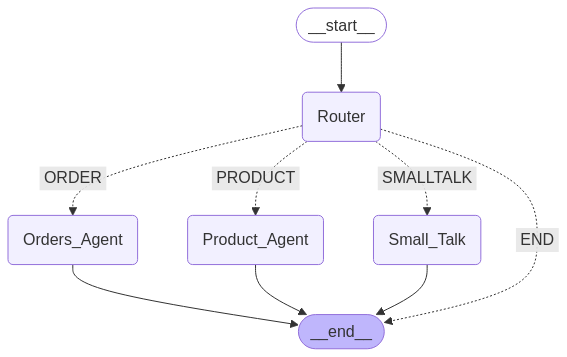

In [5]:
#Create the chatbot
from IPython.display import Image

#Setup the system problem
system_prompt = """ 
You are a Router, that analyzes the input query and chooses 4 options:
SMALLTALK: If the user input is small talk, like greetings and good byes.
PRODUCT: If the query is a product question about laptops, like features, specifications and pricing.
ORDER: If the query is about orders for laptops, like order status, order details or update order quantity
END: Default, when its neither PRODUCT or ORDER.

The output should only be just one word out of the possible 4 : SMALLTALK, PRODUCT, ORDER, END.
"""

smalltalk_prompt="""
If the user request is small talk, like greetings and goodbyes, respond professionally.
Mention that you will be able to answer questions about laptop product features and provide order status and updates.
"""

router_agent = RouterAgent(model, 
                           system_prompt, 
                           smalltalk_prompt,
                           debug=False)

Image(router_agent.router_graph.get_graph().draw_mermaid_png())

## 06.05 Execute the Routing chatbot

In [6]:
#Execute a single request
messages=[HumanMessage(content="Tell me about the features of SpectraBook")]
result=router_agent.router_graph.invoke({"messages":messages},config)
for message in result['messages']:
    print(message.pretty_repr())

================================ Human Message =================================

Tell me about the features of SpectraBook
================================== Ai Message ==================================

PRODUCT
================================== Ai Message ==================================

The SpectraBook S is a workstation-class laptop designed for power users. It features an Intel Core i9 processor, 64GB RAM, and a massive 2TB SSD, making it perfect for intensive tasks like video editing and 3D rendering.


In [7]:
#Execute a single request
messages=[HumanMessage(content="What is the status of order ORD-7311?")]
result=router_agent.router_graph.invoke({"messages":messages},config)
for message in result['messages']:
    print(message.pretty_repr())

================================ Human Message =================================

What is the status of order ORD-7311?
================================== Ai Message ==================================

ORDER
================================== Ai Message ==================================

 ORD-7311 details are as follows: 
- Product Ordered: NanoEdge Flex
- Quantity Ordered:3
- Delivery Date:2024-10-19

Your order is scheduled for delivery on the specified date. If you have any further questions or concerns, feel free to ask.


In [8]:
import uuid
#Send a sequence of messages to chatbot and get its response
#This simulates the conversation between the user and the Agentic chatbot
user_inputs = [
    "How are you doing?",
    "Please show me the details of the order ORD-7311",
    "Can you add one more of that laptop to the order? ",
    "Tell me about the features of SpectraBook laptop",
    "How much does it cost?",
    "Bye"
]

#Create a new thread
config = {"configurable": {"thread_id": str(uuid.uuid4())}}

for input in user_inputs:
    print(f"----------------------------------------\nUSER : {input}")
    #Format the user message
    user_message = {"messages":[HumanMessage(input)]}
    #Get response from the agent
    ai_response = router_agent.router_graph.invoke(user_message,config=config)
    #Print the response
    print(f"\nAGENT : {ai_response['messages'][-1].content}")


----------------------------------------
USER : How are you doing?

AGENT : : I'm doing well, thank you for asking! I'm here to help with any questions or concerns you may have. I'm ready to assist you with laptop product features, order status, and updates. How can I help you today?
----------------------------------------
USER : Please show me the details of the order ORD-7311

AGENT : The order details for ORD-7311 are as follows:
- Product Ordered: NanoEdge Flex
- Quantity Ordered: 3
- Delivery Date: 2024-10-19

Is there anything else I can assist you with regarding this order?
----------------------------------------
USER : Can you add one more of that laptop to the order? 

AGENT : The quantity of NanoEdge Flex laptops in order ORD-7311 has been updated to 4.

Would you like to make any further changes or check on the status of this order?
----------------------------------------
USER : Tell me about the features of SpectraBook laptop

AGENT : The SpectraBook S laptop features an